In [2]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from scipy.sparse import diags
from scipy.sparse.linalg import expm_multiply
from scipy.integrate import solve_ivp
plt.rcParams['figure.facecolor']='white'

We target the Hamilton-Jacobi equation with $H(x,p)=x^2/2 + p^2/2$.

If we use a level set function $\phi(t,x,p)=0$ at $p=-u(t,x)$, we end up with the level set equation
$$
    \partial_t \phi + x \partial_p \phi + p \partial_x \phi = 0.
$$
This has the form
$$
    u_t + \langle Ax, \nabla u \rangle = 0,
$$
where $A=\begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$. We then transform by letting $y=Hx$, where $H$ is the Fourier transform over $\mathbb{Z}_2$, i.e. the Hadamard transform.

This yields the transformed PDE
$$
    w_t + y_1 w_{y_1} - y_2 w_{y_2} = 0,
$$
which we know how to solve in an analog way.

If we know the solution to $w(t,y)$, we can recover $u(t,x)=w(t,Hx)$.

In [3]:

N = 256
m = 10
L = -1
R = 1

h = (R-L)/(N-1)
omega = (m * h) ** (1/2)

T = 2.0
N_t = 64
times = np.linspace(0, T, N_t)

x0_tmp, x1_tmp = np.meshgrid(np.linspace(L, R, N), np.linspace(L, R, N), indexing='ij')
X = np.stack([x0_tmp,x1_tmp], axis=-1)

X_0 = np.array([0.3, 0.7])

In [4]:
mu = -0.2
sigma = 0.15

In [5]:
u_0 = np.exp(-0.5 * ((x0_tmp - mu) / sigma) ** 2) / 2

In [6]:
psi_0 = delta_1d(x1_tmp + u_0, omega)
psi_0 /= np.linalg.norm(psi_0)

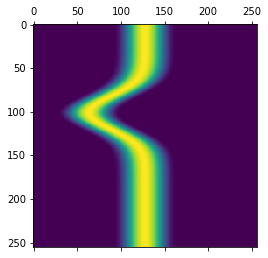

In [7]:
plt.matshow(psi_0)
plt.show()

In [8]:
psi_0_vec = psi_0.flatten(order="F")

In [9]:
x0 = np.linspace(0, R, N)
x1 = np.linspace(0, R, N)

x0_midpoints = np.zeros(N-1)
x1_midpoints = np.zeros(N-1)
for i in range(N-1):
    x0_midpoints[i] = (x0[i] + x0[i+1]) / 2
    x1_midpoints[i] = (x1[i] + x1[i+1]) / 2

In [10]:
dist_0 = np.abs(psi_0) ** 2

In [11]:
F0 = x0_midpoints
F1 = - x1_midpoints

F2 = (x0)[1:-1]
F3 = (- x1)[1:-1]

F4 = F0[1:-1]
F5 = F1[1:-1]

In [12]:
# second order central differences
F0_operator = diags([-0.5j * F0, 0.5j * F0], offsets=[1 ,-1]) / h
F1_operator = diags([-0.5j * F1, 0.5j * F1], offsets=[1 ,-1]) / h

# # fourth order central differences
# F0_operator = diags([-(2j/3) * F0, (2j/3) * F0, (1j/12) * F2, -(1j/12) * F2], offsets=[1 ,-1, 2, -2]) / h
# F1_operator = diags([-(2j/3) * F1, (2j/3) * F1, (1j/12) * F3, -(1j/12) * F3], offsets=[1 ,-1, 2, -2]) / h

# sixth order central differences
# F0_operator = diags([-(3j/4) * F0, (3j/4) * F0, (3j/20) * F2, -(3j/20) * F2, -(1/60) * F4, (1/60) * F4], offsets=[1 ,-1, 2, -2, 3, -3]) / h
# F1_operator = diags([-(3j/4) * F1, (3j/4) * F1, (3j/20) * F3, -(3j/20) * F3, -(1/60) * F5, (1/60) * F5], offsets=[1 ,-1, 2, -2, 3, -3]) / h

In [13]:
# F0_operator.toarray()

In [14]:
H = kron(np.eye(N), F0_operator) + kron(F1_operator, np.eye(N))


In [15]:
# plt.matshow(H.toarray().imag)
# plt.show()

In [16]:
psi = expm_multiply(-1j * H, psi_0_vec, 0, T, N_t)

In [17]:
X_sol = np.zeros((N_t, 2))

In [18]:
np.sum(np.abs(psi[40]) ** 2)

1.0

In [19]:
for i in range(N_t):
    dist = np.reshape(np.abs(psi[i]) ** 2, (N,N), order="F")
    X_sol[i,0] = np.sum(np.multiply(dist.T, x0))
    X_sol[i,1] = np.sum(np.multiply(dist, x1))

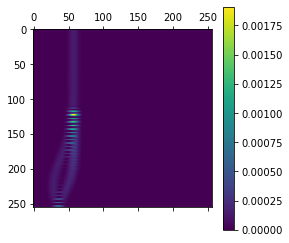

In [20]:
im = plt.matshow(np.reshape(np.abs(psi[50]) ** 2, (N,N), order="F"))
plt.colorbar(im)
plt.show()

In [21]:
np.sum(np.abs(psi[10])**2)

0.9999999999999998

In [22]:
import matplotlib as mpl
import matplotlib.animation as animation

In [23]:
filename = "second_order.gif"

.................

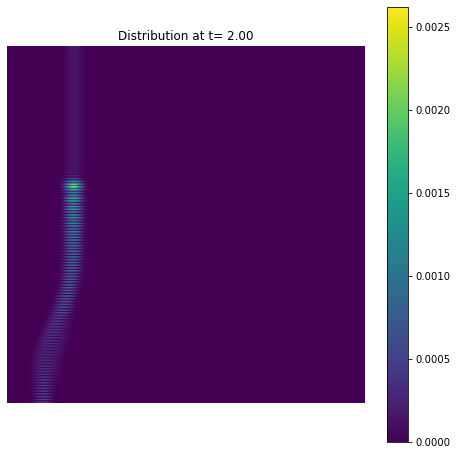

In [24]:
fps = 4
snapshots = [np.reshape(np.abs(psi[i]) ** 2, (N,N), order="F") for i in range(N_t)]
# First set up the figure, the axis, and the plot element we want to animate
fig = plt.figure(figsize=(8,8))

norm = mpl.colors.Normalize(vmin=0, vmax=np.max(snapshots[0]))
a = snapshots[0]
im = plt.imshow(a)
plt.title(f"Distribution at t={times[0] : 0.2f}")
cb = plt.colorbar(im)
plt.axis("off")

def animate(i):
    if i % fps == 0:
        print( '.', end ='' )

    # plt.imshow(snapshots[i])
    im.set_data(snapshots[i])
    norm = mpl.colors.Normalize(vmin=0, vmax=np.max(snapshots[i]))
    im.set_norm(norm)
    plt.title(f"Distribution at t={times[i] : 0.2f}")
    return [im]

anim = animation.FuncAnimation(fig, 
                               animate, 
                               frames=len(snapshots),
                               interval = 1000 # in ms
                               )
writergif = animation.PillowWriter(fps=fps)
anim.save(filename, writer=writergif)

In [178]:
H = np.array([[1,1],[1,-1]] / np.sqrt(2))

In [180]:
Y = H @ np.stack([x0,x1])